Some very bad and simplified predictions for time series data 

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
cleaned_df = pd.read_csv("Data/cleaned_df.csv")
cleaned_df["Date"] = pd.to_datetime(cleaned_df["Date"])

/var/folders/58/r3zgxt3d0g361_lmqmt90gfh0000gn/T/ipykernel_9466/1588351069.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])


(array([ 8035.,  9496., 10957., 12418., 13879., 15340., 16801., 18262.,
        19723., 21184.]),
 [Text(8035.0, 0, '1992'),
  Text(9496.0, 0, '1996'),
  Text(10957.0, 0, '2000'),
  Text(12418.0, 0, '2004'),
  Text(13879.0, 0, '2008'),
  Text(15340.0, 0, '2012'),
  Text(16801.0, 0, '2016'),
  Text(18262.0, 0, '2020'),
  Text(19723.0, 0, '2024'),
  Text(21184.0, 0, '2028')])

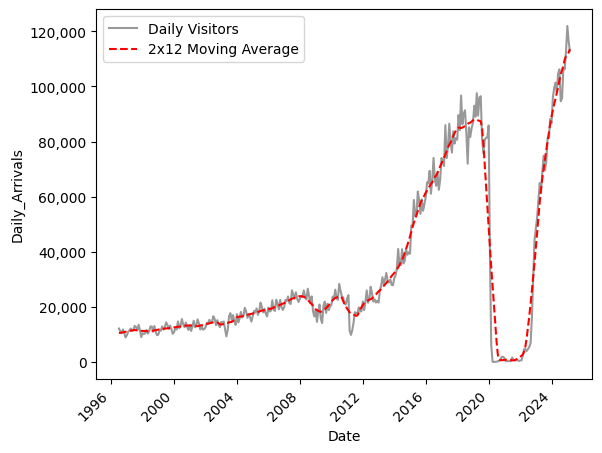

In [2]:
# First test - naive method
sns.lineplot(data = cleaned_df, x = "Date", y = "Daily_Arrivals", 
             alpha = 0.8, 
             color = "Gray", label = "Daily Visitors")
sns.lineplot(data = cleaned_df, x = "Date", y = "Daily_Arrivals_Moving_Avg", 
             alpha = 1, 
             color = "Red",linestyle = "--", label = "2x12 Moving Average")

current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])
plt.xticks(rotation=45, ha="right")


In [3]:
# Creating predictive df with next 12 months included 
import numpy as np


monthly_dates = pd.date_range(start=np.datetime64('2025-04-01'), end = '2027-03-01', freq = 'MS')
new_data = pd.DataFrame({
    'Date': monthly_dates,
    'Daily_Arrivals': [0] * 24,
    'Year': monthly_dates.year,
    'Daily_Arrivals': cleaned_df["Daily_Arrivals"].iloc[-1]
})

df_naive = pd.concat([cleaned_df, new_data], ignore_index=True)

/var/folders/58/r3zgxt3d0g361_lmqmt90gfh0000gn/T/ipykernel_9466/2745687204.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])


(array([ 8035.,  9496., 10957., 12418., 13879., 15340., 16801., 18262.,
        19723., 21184.]),
 [Text(8035.0, 0, '1992'),
  Text(9496.0, 0, '1996'),
  Text(10957.0, 0, '2000'),
  Text(12418.0, 0, '2004'),
  Text(13879.0, 0, '2008'),
  Text(15340.0, 0, '2012'),
  Text(16801.0, 0, '2016'),
  Text(18262.0, 0, '2020'),
  Text(19723.0, 0, '2024'),
  Text(21184.0, 0, '2028')])

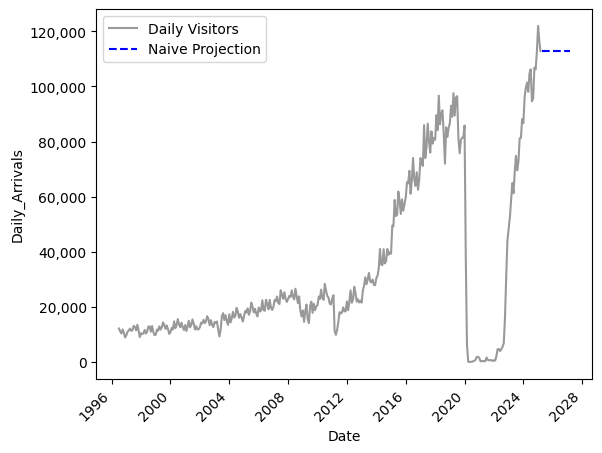

In [4]:
# Graphing the naive method of doing things
sns.lineplot(data = df_naive.iloc[:-24,:], x = "Date", y = "Daily_Arrivals", 
             alpha = 0.8, 
             color = "Gray", label = "Daily Visitors")
sns.lineplot(data = df_naive.iloc[-24:, :], x = "Date", y = "Daily_Arrivals", 
             alpha = 1, 
             color = "blue",linestyle = "--", label = "Naive Projection")

current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])
plt.xticks(rotation=45, ha="right")

In [5]:
new_data = pd.DataFrame({
    'Date': monthly_dates,
    'Daily_Arrivals': [0] * 24,
    'Year': monthly_dates.year,
    'Daily_Arrivals': cleaned_df["Daily_Arrivals"].mean()
})

df_avg = pd.concat([cleaned_df, new_data], ignore_index=True)

/var/folders/58/r3zgxt3d0g361_lmqmt90gfh0000gn/T/ipykernel_9466/6458803.py:9: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])


(array([ 8035.,  9496., 10957., 12418., 13879., 15340., 16801., 18262.,
        19723., 21184.]),
 [Text(8035.0, 0, '1992'),
  Text(9496.0, 0, '1996'),
  Text(10957.0, 0, '2000'),
  Text(12418.0, 0, '2004'),
  Text(13879.0, 0, '2008'),
  Text(15340.0, 0, '2012'),
  Text(16801.0, 0, '2016'),
  Text(18262.0, 0, '2020'),
  Text(19723.0, 0, '2024'),
  Text(21184.0, 0, '2028')])

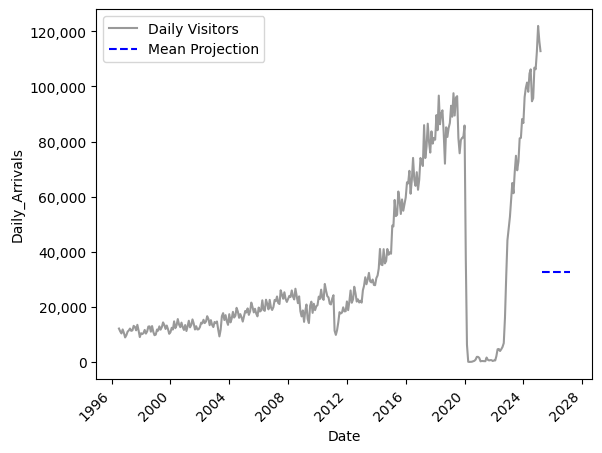

In [6]:
sns.lineplot(data = df_avg.iloc[:-24,:], x = "Date", y = "Daily_Arrivals", 
             alpha = 0.8, 
             color = "Gray", label = "Daily Visitors")
sns.lineplot(data = df_avg.iloc[-24:, :], x = "Date", y = "Daily_Arrivals", 
             alpha = 1, 
             color = "blue",linestyle = "--", label = "Mean Projection")

current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])
plt.xticks(rotation=45, ha="right")

/var/folders/58/r3zgxt3d0g361_lmqmt90gfh0000gn/T/ipykernel_9466/3349558357.py:19: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])


(array([ 8035.,  9496., 10957., 12418., 13879., 15340., 16801., 18262.,
        19723., 21184.]),
 [Text(8035.0, 0, '1992'),
  Text(9496.0, 0, '1996'),
  Text(10957.0, 0, '2000'),
  Text(12418.0, 0, '2004'),
  Text(13879.0, 0, '2008'),
  Text(15340.0, 0, '2012'),
  Text(16801.0, 0, '2016'),
  Text(18262.0, 0, '2020'),
  Text(19723.0, 0, '2024'),
  Text(21184.0, 0, '2028')])

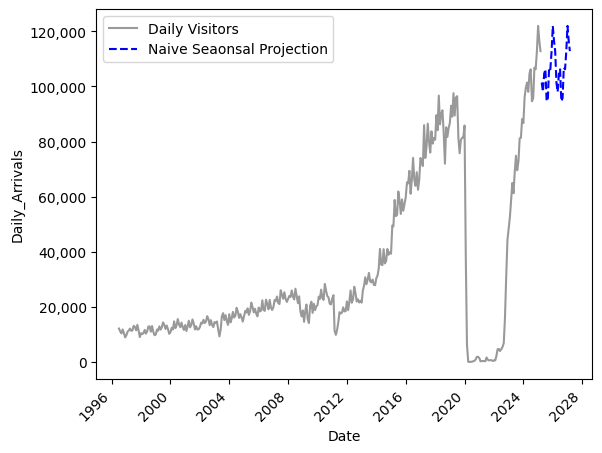

In [7]:
new_data = pd.DataFrame({
    'Date': monthly_dates,
    'Daily_Arrivals': [0] * 24,
    'Year': monthly_dates.year,
    'Daily_Arrivals': cleaned_df["Daily_Arrivals"].iloc[-12:,].tolist() * 2
})

df_seasonal = pd.concat([cleaned_df, new_data], ignore_index=True)


sns.lineplot(data = df_seasonal.iloc[:-24,:], x = "Date", y = "Daily_Arrivals", 
             alpha = 0.8, 
             color = "Gray", label = "Daily Visitors")
sns.lineplot(data = df_seasonal.iloc[-24:, :], x = "Date", y = "Daily_Arrivals", 
             alpha = 1, 
             color = "blue",linestyle = "--", label = "Naive Seaonsal Projection")

current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])
plt.xticks(rotation=45, ha="right")


/var/folders/58/r3zgxt3d0g361_lmqmt90gfh0000gn/T/ipykernel_9466/2973256490.py:19: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])


(array([16801., 17532., 18262., 18993., 19723., 20454., 21184.]),
 [Text(16801.0, 0, '2016'),
  Text(17532.0, 0, '2018'),
  Text(18262.0, 0, '2020'),
  Text(18993.0, 0, '2022'),
  Text(19723.0, 0, '2024'),
  Text(20454.0, 0, '2026'),
  Text(21184.0, 0, '2028')])

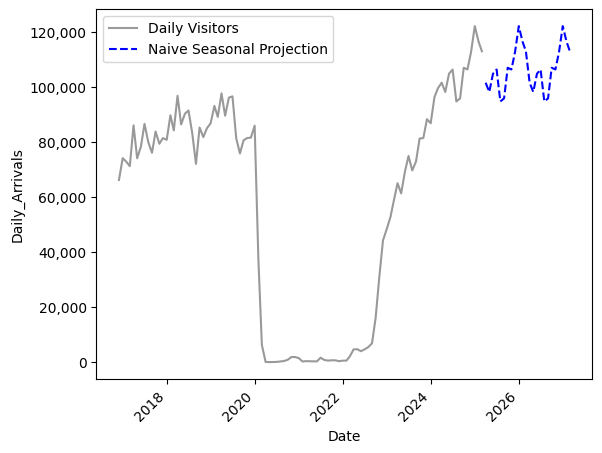

In [8]:
new_data = pd.DataFrame({
    'Date': monthly_dates,
    'Daily_Arrivals': [0] * 24,
    'Year': monthly_dates.year,
    'Daily_Arrivals': cleaned_df["Daily_Arrivals"].iloc[-12:,].tolist() * 2
})

df_seasonal = pd.concat([cleaned_df, new_data], ignore_index=True)


sns.lineplot(data = df_seasonal.iloc[245:-24,:], x = "Date", y = "Daily_Arrivals", 
             alpha = 0.8, 
             color = "Gray", label = "Daily Visitors")
sns.lineplot(data = df_seasonal.iloc[-24:, :], x = "Date", y = "Daily_Arrivals", 
             alpha = 1, 
             color = "blue",linestyle = "--", label = "Naive Seasonal Projection")

current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])
plt.xticks(rotation=45, ha="right")


/var/folders/58/r3zgxt3d0g361_lmqmt90gfh0000gn/T/ipykernel_9466/4256455957.py:25: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])


(array([16801., 17532., 18262., 18993., 19723., 20454., 21184.]),
 [Text(16801.0, 0, '2016'),
  Text(17532.0, 0, '2018'),
  Text(18262.0, 0, '2020'),
  Text(18993.0, 0, '2022'),
  Text(19723.0, 0, '2024'),
  Text(20454.0, 0, '2026'),
  Text(21184.0, 0, '2028')])

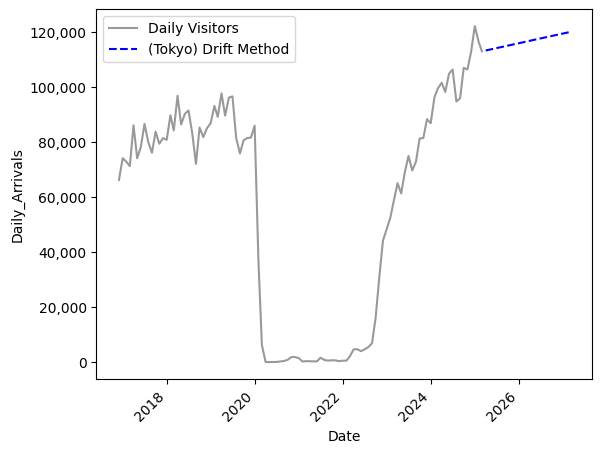

In [9]:
# Lastly, the (Tokyo) drift method

increment = (cleaned_df["Daily_Arrivals"].iloc[-1,] - cleaned_df["Daily_Arrivals"].iloc[0,])/(len(cleaned_df) - 1)
extrapolated = np.arange(cleaned_df["Daily_Arrivals"].iloc[-1,] + increment, \
                         cleaned_df["Daily_Arrivals"].iloc[-1,] + increment * 24, increment)

new_data = pd.DataFrame({
    'Date': monthly_dates,
    'Daily_Arrivals': [0] * 24,
    'Year': monthly_dates.year,
    'Daily_Arrivals': extrapolated
})

df_seasonal = pd.concat([cleaned_df, new_data], ignore_index=True)


sns.lineplot(data = df_seasonal.iloc[245:-24,:], x = "Date", y = "Daily_Arrivals", 
             alpha = 0.8, 
             color = "Gray", label = "Daily Visitors")
sns.lineplot(data = df_seasonal.iloc[-24:, :], x = "Date", y = "Daily_Arrivals", 
             alpha = 1, 
             color = "blue",linestyle = "--", label = "(Tokyo) Drift Method")

current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])
plt.xticks(rotation=45, ha="right")


/var/folders/58/r3zgxt3d0g361_lmqmt90gfh0000gn/T/ipykernel_9466/2007582617.py:19: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])


(array([ 8035.,  9496., 10957., 12418., 13879., 15340., 16801., 18262.,
        19723., 21184.]),
 [Text(8035.0, 0, '1992'),
  Text(9496.0, 0, '1996'),
  Text(10957.0, 0, '2000'),
  Text(12418.0, 0, '2004'),
  Text(13879.0, 0, '2008'),
  Text(15340.0, 0, '2012'),
  Text(16801.0, 0, '2016'),
  Text(18262.0, 0, '2020'),
  Text(19723.0, 0, '2024'),
  Text(21184.0, 0, '2028')])

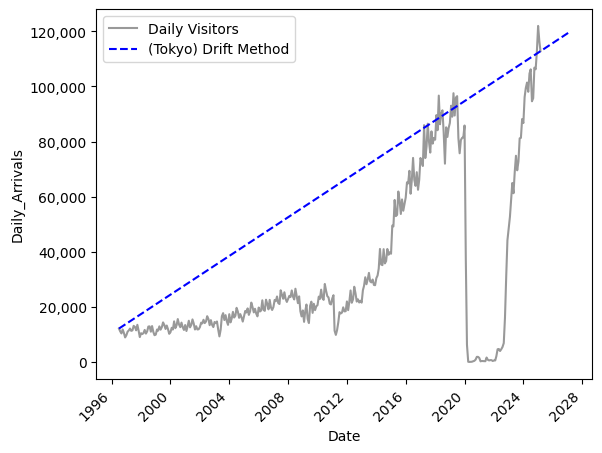

In [10]:
# Lastly, the (Tokyo) drift method
seasonal_time = np.arange(cleaned_df["Daily_Arrivals"].iloc[0,],\
                                                cleaned_df["Daily_Arrivals"].iloc[-1,] + increment * 25, increment)



df_seasonal["extrapolated_plus"] = seasonal_time



sns.lineplot(data = df_seasonal.iloc[:-24,], x = "Date", y = "Daily_Arrivals", 
             alpha = 0.8, 
             color = "Gray", label = "Daily Visitors")
sns.lineplot(data = df_seasonal, x = "Date", y = "extrapolated_plus", 
             alpha = 1, 
             color = "blue",linestyle = "--", label = "(Tokyo) Drift Method")

current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])
plt.xticks(rotation=45, ha="right")

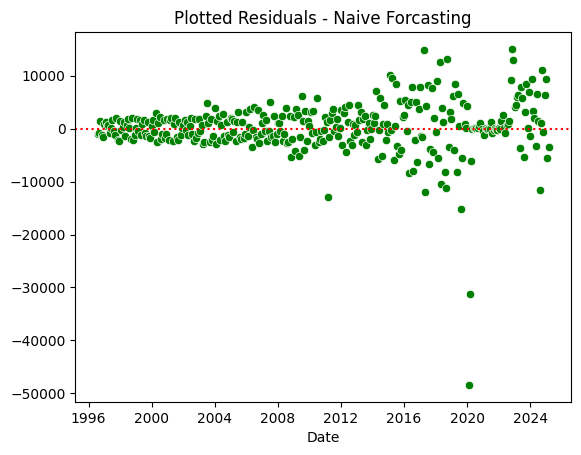

In [49]:
# Testing Residuals for the naive method

y_hat = cleaned_df["Daily_Arrivals"].to_numpy()[0:-1]
y = cleaned_df["Daily_Arrivals"].to_numpy()[1:]
resid = y - y_hat
sns.scatterplot(x = cleaned_df["Date"][1:], y = resid, color = "g")
plt.title(label = "Plotted Residuals - Naive Forcasting")
plt.axhline(y = 0, color='red', linestyle=':') 
plt.show()


It's good that the residuals appear to be unbiased, but they are demonstrating hetroscedasticity (changing variance.) I want to run a log transform on the data and see if that fixes things. Epic fail - I'm just going to redo this with a box-cox transformation

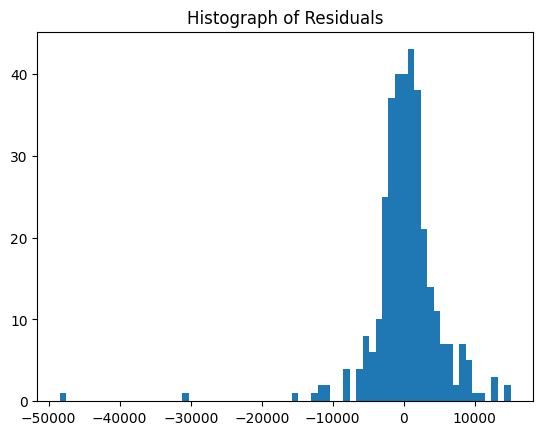

In [53]:
plt.hist(x = resid, bins = 70)
plt.title(label = "Histograph of Residuals")
plt.show()

Looks pretty, good, maybe a bit too lage of a tail to the left (however, it somehow balances out the stuff on the right)

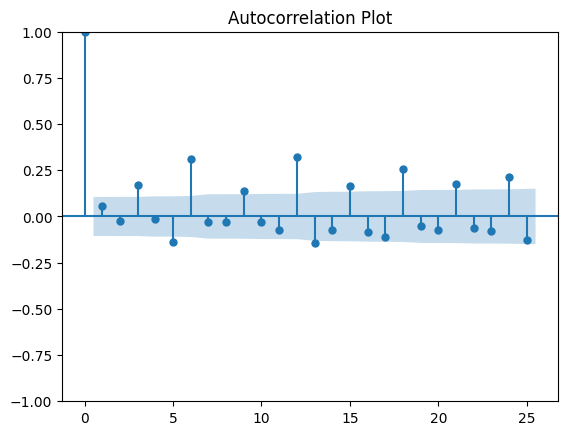

In [59]:
from statsmodels.graphics.tsaplots import plot_acf

# 'data' should be a 1D array or pandas Series
plot_acf(resid, lags = 25)
plt.title(label = "Autocorrelation Plot")
plt.show()

Looks pretty good, outside of first part (correlation of residual with itself), the autocorrelation appears to be pretty random
## Next Step: Calculating Standard Deviation of residuals
We now want to calcualte the standard deviation of the residuals

$\hat{\sigma} = \sqrt{\frac{1}{T-K-M}\sum{e_t^2}}$

Where T is number of times, K is number of parameters estimated in the forecasting method, and M is the number of missing values in the residuals (M = 1 for naive forecast because we don't forecast first observation)

In [68]:
std = np.sqrt((1/343)* np.sum(np.square(resid)))
std

# Note - don't think this actually works because residuals are not normal. They increase as they go...

5092.334516048711